In [4]:
data.head(30)

,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa)
0,0,2024-01-01T00:00,7.7,77,30.6,0.0,0,48.2,51.8,246,243,90,0.25
1,0,2024-01-01T01:00,7.6,77,29.5,0.0,0,47.4,50.8,249,246,60,0.24
2,0,2024-01-01T02:00,7.3,78,29.0,0.0,0,47.0,49.3,248,245,22,0.22
3,0,2024-01-01T03:00,7.0,80,26.8,0.0,0,44.1,48.2,251,248,33,0.20
4,0,2024-01-01T04:00,6.9,80,26.0,0.0,0,42.7,44.6,254,251,46,0.20
5,0,2024-01-01T05:00,6.8,79,26.2,0.0,0,43.3,43.6,255,252,32,0.20
6,0,2024-01-01T06:00,6.8,75,26.0,0.0,0,43.3,44.6,259,256,10,0.24
7,0,2024-01-01T07:00,6.4,74,24.9,0.0,0,41.8,43.2,259,256,93,0.25
8,0,2024-01-01T08:00,6.2,71,22.9,0.0,0,39.4,41.0,261,257,98,0.27
9,0,2024-01-01T09:00,5.8,71,19.6,0.0,0,35.5,37.8,260,256,100,0.27


In [25]:
import pandas as pd
import numpy as np

In [26]:
data = pd.read_csv("Weather-2020-2025.csv")

In [27]:
data = data.dropna()

In [28]:
daytime_data = data[data['is_day'] == 1]

#daytime temperature averages
daytime_data.groupby("location_id")["temperature_2m"].mean()


location_id
0    14.285160
1    12.855252
2    19.595864
Name: temperature_2m, dtype: float64

In [9]:
nighttime_data = data[data['is_day'] == 0]

#daytime temperature averages
nighttime_data.groupby("location_id")["temperature_2m"].mean()

location_id
0     9.741029
1     9.517392
2    15.247273
Name: temperature_2m, dtype: float64

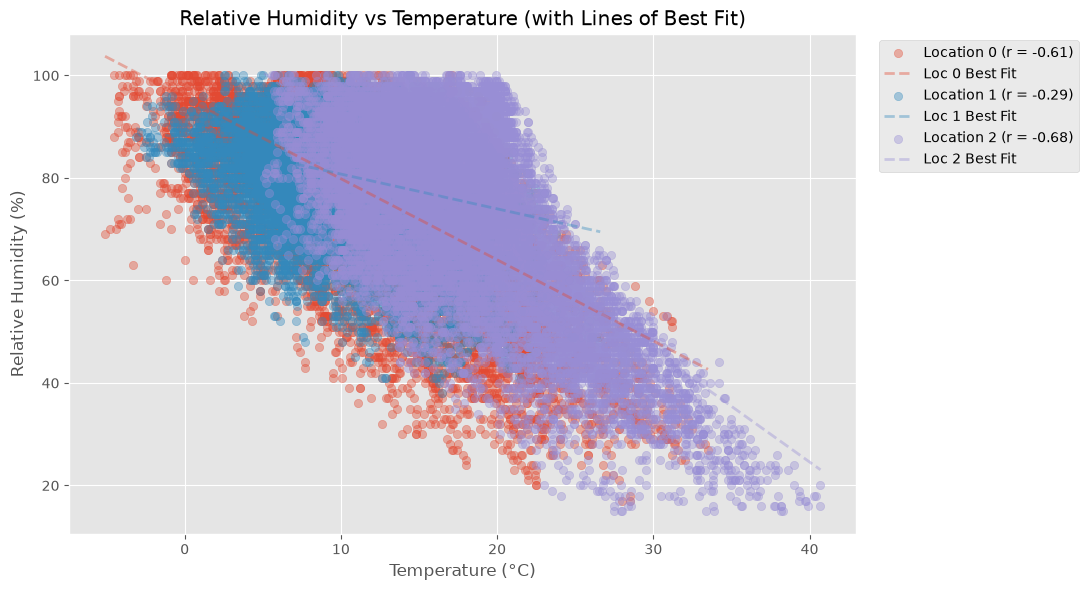

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: set a clean background style for your presentation
plt.style.use('ggplot')

# Create one large figure for all three locations
plt.figure(figsize=(11, 6))

# Loop through each unique location ID in your dataset automatically
for loc_id in data['location_id'].unique():
    
    # 1. Filter the data for the current location (just like your Lisbon example)
    loc_df = data[data["location_id"] == loc_id].copy()
    
    # 2. Calculate the specific correlation value between Temp and Humidity
    corr_val = loc_df["temperature_2m"].corr(loc_df["relative_humidity_2m (%)"])
    
    # 3. Plot the scatter points 
    # We include the correlation score (r) directly in the label so it prints in the legend!
    scatter = plt.scatter(
        loc_df["temperature_2m"], 
        loc_df["relative_humidity_2m (%)"], 
        alpha=0.4, 
        label=f"Location {loc_id} (r = {corr_val:.2f})"
    )
    
    # Get the color of the scatter dots so the line matches perfectly
    line_color = scatter.get_facecolor()[0] 
    
    # 4. Plot the line of best fit using your exact polyfit template logic
    x = np.unique(loc_df["temperature_2m"])
    fit_function = np.poly1d(np.polyfit(loc_df["temperature_2m"], loc_df["relative_humidity_2m (%)"], 1))
    y = fit_function(x)
    
    plt.plot(x, y, label=f"Loc {loc_id} Best Fit", color=line_color, linewidth=2, linestyle="--")

# 5. Final touches to label your axes and clean up the chart
plt.title("Relative Humidity vs Temperature (with Lines of Best Fit)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")

# Places the legend slightly outside the chart so it doesn't block any data points
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()

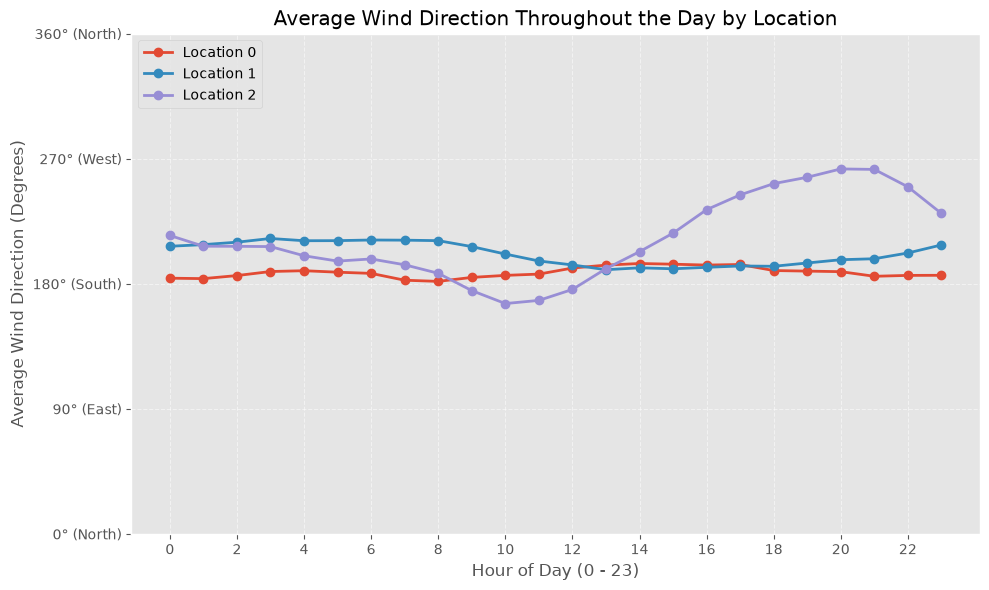

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure time is in the correct format and extract the hour
data['time'] = pd.to_datetime(data['time'])
data['Hour'] = data['time'].dt.hour

# 2. Calculate the average wind direction for each hour for each location
# This groups the data and cleans up the messy scatter dots into averages
hourly_avg_wind = data.groupby(['Hour', 'location_id'])['wind_direction_10m'].mean().unstack()

# 3. Create the single, simple line plot
plt.figure(figsize=(10, 6))

for location in hourly_avg_wind.columns:
    plt.plot(
        hourly_avg_wind.index, 
        hourly_avg_wind[location], 
        marker='o',          # Adds a clean dot at each hour
        linewidth=2, 
        label=f'Location {location}'
    )

# 4. Add clear labels and a grid for easy reading
plt.title('Average Wind Direction Throughout the Day by Location')
plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Average Wind Direction (Degrees)')

# Set specific marks for the compass directions on the Y-axis to make it easy to read
plt.yticks([0, 90, 180, 270, 360], ['0° (North)', '90° (East)', '180° (South)', '270° (West)', '360° (North)'])
plt.xticks(range(0, 24, 2)) # Shows hours every 2 hours on the bottom axis

plt.grid(True, linestyle='--', alpha=0.5) # Adds a clean background grid
plt.legend(loc='upper left')
plt.tight_layout()

# Show the simplified graph
plt.show()


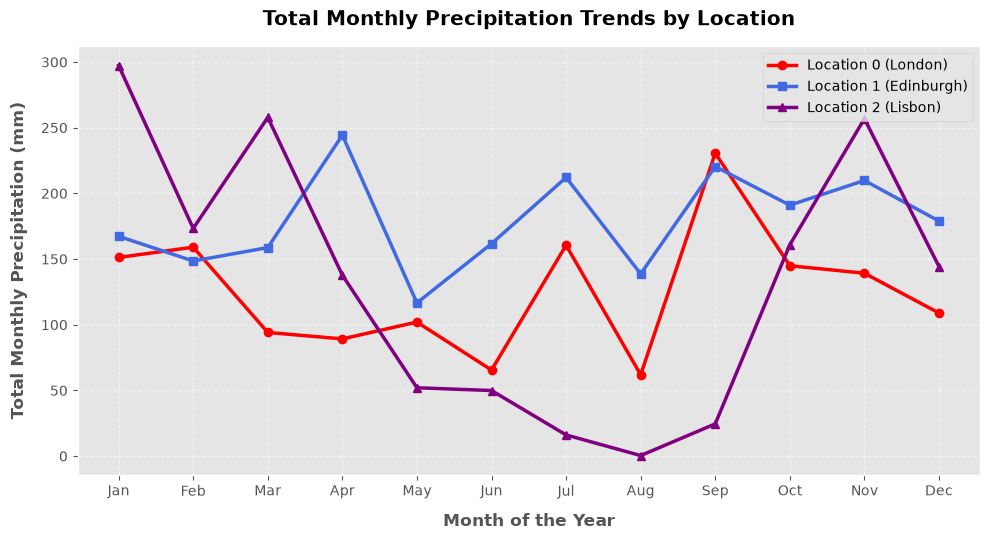

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure time is in the correct format and extract the Month number
data['time'] = pd.to_datetime(data['time'])
data['Month'] = data['time'].dt.month

# 2. Filter data into individual datasets for each city
london = data[data["location_id"] == 0].copy()
edinburgh = data[data["location_id"] == 1].copy()
lisbon = data[data["location_id"] == 2].copy()

# 3. Sum up the precipitation for each month across all days and years
# Note: Using the exact column name 'precipitation (mm)' to prevent errors
london_monthly = london.groupby('Month')['precipitation (mm)'].sum().reset_index()
edinburgh_monthly = edinburgh.groupby('Month')['precipitation (mm)'].sum().reset_index()
lisbon_monthly = lisbon.groupby('Month')['precipitation (mm)'].sum().reset_index()

# 4. Create a clean, easy-to-read line graph
plt.figure(figsize=(10, 5.5))

plt.plot(london_monthly["Month"], london_monthly["precipitation (mm)"], label="Location 0 (London)", color='red', marker='o', linewidth=2.5)
plt.plot(edinburgh_monthly["Month"], edinburgh_monthly["precipitation (mm)"], label="Location 1 (Edinburgh)", color='royalblue', marker='s', linewidth=2.5)
plt.plot(lisbon_monthly["Month"], lisbon_monthly["precipitation (mm)"], label="Location 2 (Lisbon)", color='purple', marker='^', linewidth=2.5)

# 5. Format X and Y axes for professional presentation slides
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_names)
plt.xlabel('Month of the Year', fontweight='bold', labelpad=10)
plt.ylabel('Total Monthly Precipitation (mm)', fontweight='bold', labelpad=10)
plt.title('Total Monthly Precipitation Trends by Location', fontweight='bold', pad=15)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

# Save chart for your slides
plt.savefig('monthly_precipitation_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

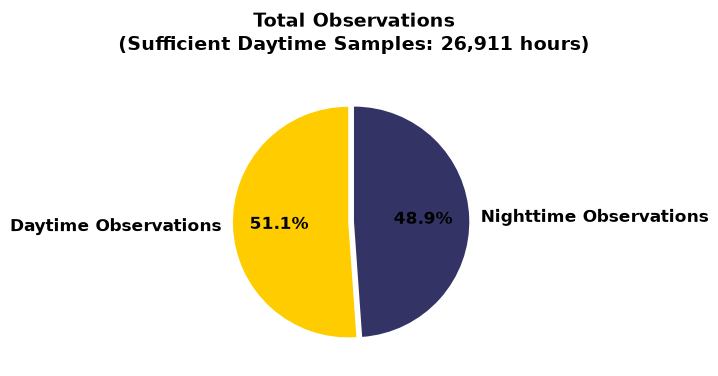

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Count how many total day vs night readings are in the dataset
# (is_day == 1 means Day, is_day == 0 means Night)
day_night_counts = data['is_day'].value_counts()

# 2. Create a clean, professional pie chart
plt.figure(figsize=(7, 7))
colors = ['#ffcc00', '#333366'] # Sunny Gold for Day, Deep Midnight Blue for Night

plt.pie(
    day_night_counts, 
    labels=['Daytime Observations', 'Nighttime Observations'], 
    autopct='%1.1f%%', # Shows the exact percentage on the slice
    startangle=90, 
    colors=colors,
    textprops={'fontsize': 12, 'weight': 'bold'},
    explode=(0.05, 0) # Slightly separates the daytime slice to highlight it
)

# 3. Add a title and note showing the huge number of samples
total_day_samples = day_night_counts[1]
plt.title(f'Total Observations\n(Sufficient Daytime Samples: {total_day_samples:,} hours)', 
          fontweight='bold', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('data_sufficiency_pie_chart.png', dpi=150)
plt.show()

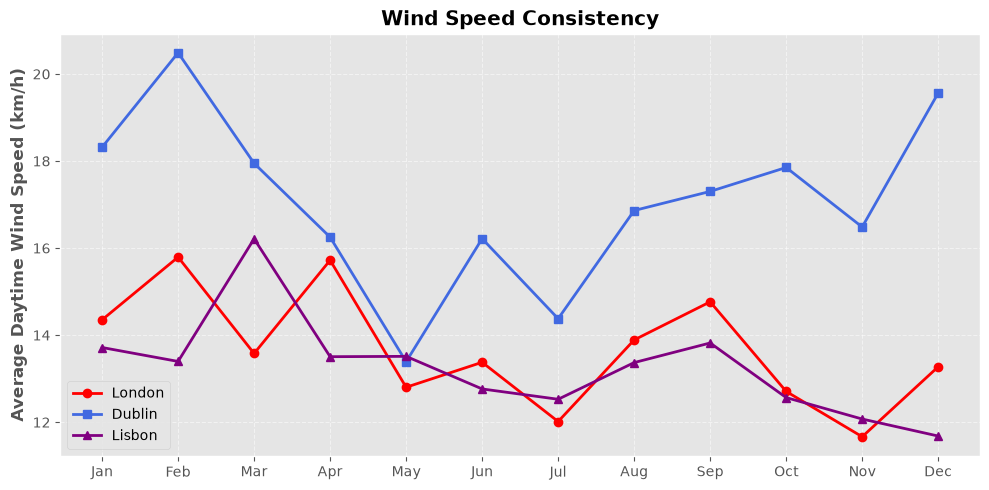

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Step A: Create the Month column in the main dataset FIRST
data['time'] = pd.to_datetime(data['time'])
data['Month'] = data['time'].dt.month

# 2. Step B: NOW create the daytime-only copy (it will successfully include 'Month' now)
day_data = data[data['is_day'] == 1].copy()

# 3. Group by Month and find the average daytime wind speed
# Note: Double check if your column has a space or not: 'wind_speed_10m(km/h)'
monthly_wind = day_data.groupby(['Month', 'location_id'])['wind_speed_10m (km/h)'].mean().unstack()
monthly_wind.columns = ['London', 'Dublin', 'Lisbon']

# 4. Plotting
plt.figure(figsize=(10, 5))
plt.plot(monthly_wind.index, monthly_wind['London'], marker='o', color='red', linewidth=2, label='London')
plt.plot(monthly_wind.index, monthly_wind['Dublin'], marker='s', color='royalblue', linewidth=2, label='Dublin')
plt.plot(monthly_wind.index, monthly_wind['Lisbon'], marker='^', color='purple', linewidth=2, label='Lisbon')

# Formatting
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_names)
plt.ylabel('Average Daytime Wind Speed (km/h)', fontweight='bold')
plt.title('Wind Speed Consistency', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('wind_consistency_kmh.png', dpi=150)
plt.show()

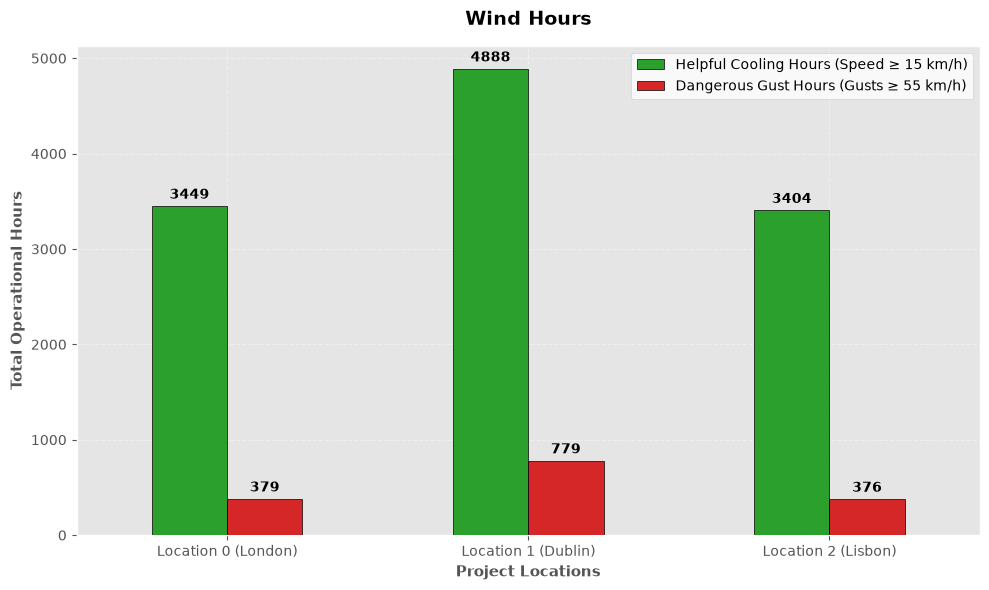

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure the Month column and daytime filter are active
data['time'] = pd.to_datetime(data['time'])
data['Month'] = data['time'].dt.month
day_data = data[data['is_day'] == 1].copy()

# 2. Convert km/h thresholds: 
# Optimal cooling wind speed >= 15 km/h
# Dangerous wind gusts >= 55 km/h
day_data['Is_Cooling'] = day_data['wind_speed_10m (km/h)'] >= 15
day_data['Is_Dangerous'] = day_data['wind_gusts_10m (km/h)'] >= 55

# 3. Count total daytime hours matching these physical conditions for each location
summary = day_data.groupby('location_id').agg({
    'Is_Cooling': 'sum',
    'Is_Dangerous': 'sum'
}).copy()

# Rename for presentation labels
summary.index = ['Location 0 (London)', 'Location 1 (Dublin)', 'Location 2 (Lisbon)']
summary.columns = ['Helpful Cooling Hours (Speed ≥ 15 km/h)', 'Dangerous Gust Hours (Gusts ≥ 55 km/h)']

# 4. Create a clean, simple Grouped Bar Chart
ax = summary.plot(kind='bar', figsize=(10, 6), color=['#2ca02c', '#d62728'], edgecolor='black', zorder=3)

# Formatting labels and grid
plt.title('Wind Hours', fontweight='bold', fontsize=14, pad=15)
plt.ylabel('Total Operational Hours', fontweight='bold', fontsize=11)
plt.xlabel('Project Locations', fontweight='bold', fontsize=11)
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.4, zorder=0)
plt.legend(frameon=True, facecolor='white')

# Add number labels on top of the bars so they are easy to read
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontweight='bold', padding=3)

plt.tight_layout()
plt.savefig('wind_physics_bar_chart.png', dpi=150)
plt.show()